In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [2]:
# Load, clean, and prepare the datasets for analysis.

In [3]:
advice_df = pd.read_csv("data/Advice-Seeking Keyword Comparison.csv")

study_df = pd.read_csv("data/Study Support Keyword Comparison.csv")

study_df.columns.name = None

general_df = pd.read_csv("data/General Help-Seeking Keyword Comparison.csv")

advice_df = advice_df.replace("<1", "0.5")
study_df = study_df.replace("<1", "0.5")
general_df = general_df.replace("<1", "0.5")

advice_df["Time"] = pd.to_datetime(advice_df["Time"])
study_df["Week"] = pd.to_datetime(study_df["Week"])
general_df["Time"] = pd.to_datetime(general_df["Time"])

advice_df["Yahoo Answers"] = pd.to_numeric(advice_df["Yahoo Answers"])
advice_df["Ask.fm"] = pd.to_numeric(advice_df["Ask.fm"])
advice_df["ai friend"] = pd.to_numeric(advice_df["ai friend"])

study_df["course hero: (Worldwide)"] = pd.to_numeric(study_df["course hero: (Worldwide)"])
study_df["chatgpt study: (Worldwide)"] = pd.to_numeric(study_df["chatgpt study: (Worldwide)"])
study_df["chegg: (Worldwide)"] = pd.to_numeric(study_df["chegg: (Worldwide)"])

general_df["quora"] = pd.to_numeric(general_df["quora"])
general_df["chatgpt help"] = pd.to_numeric(general_df["chatgpt help"])

print(advice_df.head())
print(study_df.head())
print(general_df.head())

        Time  Yahoo Answers  Ask.fm  ai friend
0 2021-04-01             56      13          2
1 2021-05-01             22      12          2
2 2021-06-01             14      12          2
3 2021-07-01             12      11          2
4 2021-08-01             11      11          3
        Week  course hero: (Worldwide)  chatgpt study: (Worldwide)  \
0 2021-04-11                        15                         0.0   
1 2021-04-18                        16                         0.0   
2 2021-04-25                        16                         0.0   
3 2021-05-02                        15                         0.0   
4 2021-05-09                        13                         0.0   

   chegg: (Worldwide)  
0                  71  
1                  66  
2                  66  
3                  61  
4                  56  
        Time  quora  chatgpt help
0 2021-04-01     70             0
1 2021-05-01     81             0
2 2021-06-01     80             0
3 2021-07-01     

In [4]:
# Plot the trends of Yahoo Answers, Ask.fm, and ai friend over time.

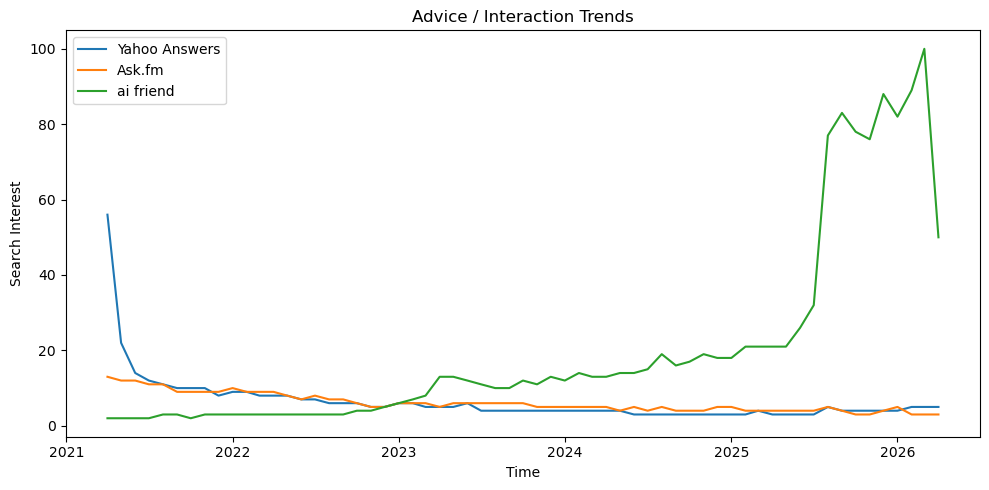

In [5]:
plt.figure(figsize=(10,5))
plt.plot(advice_df["Time"], advice_df["Yahoo Answers"], label="Yahoo Answers")
plt.plot(advice_df["Time"], advice_df["Ask.fm"], label="Ask.fm")
plt.plot(advice_df["Time"], advice_df["ai friend"], label="ai friend")
plt.title("Advice / Interaction Trends")
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Plot the trends of quora and chatgpt help over time.

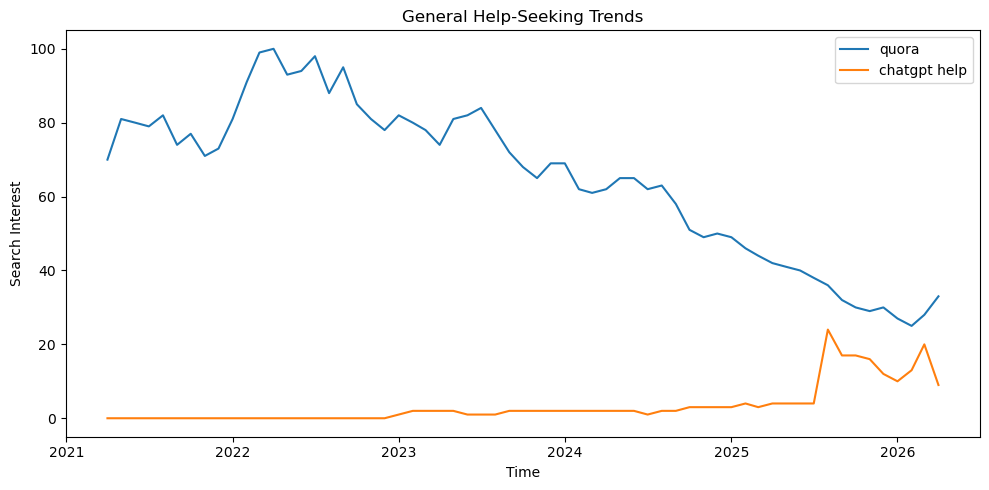

In [7]:
plt.figure(figsize=(10,5))
plt.plot(general_df["Time"], general_df["quora"], label="quora")
plt.plot(general_df["Time"], general_df["chatgpt help"], label="chatgpt help")
plt.title("General Help-Seeking Trends")
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Plot the trends of course hero, chatgpt study, and chegg over time.

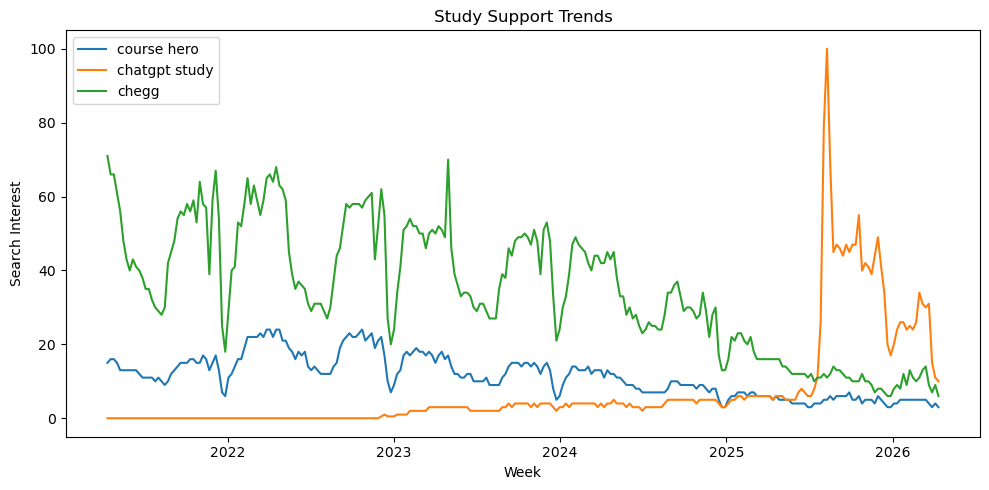

In [9]:
plt.figure(figsize=(10,5))
plt.plot(study_df["Week"], study_df["course hero: (Worldwide)"], label="course hero")
plt.plot(study_df["Week"], study_df["chatgpt study: (Worldwide)"], label="chatgpt study")
plt.plot(study_df["Week"], study_df["chegg: (Worldwide)"], label="chegg")
plt.title("Study Support Trends")
plt.xlabel("Week")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Display summary statistics for each dataset.

In [11]:
print(advice_df[["Yahoo Answers", "Ask.fm", "ai friend"]].describe())
print(general_df[["quora", "chatgpt help"]].describe())
print(study_df[["course hero: (Worldwide)", "chatgpt study: (Worldwide)", "chegg: (Worldwide)"]].describe())

       Yahoo Answers     Ask.fm   ai friend
count      61.000000  61.000000   61.000000
mean        6.508197   6.081967   20.573770
std         7.237916   2.491954   26.457802
min         3.000000   3.000000    2.000000
25%         4.000000   4.000000    3.000000
50%         5.000000   5.000000   12.000000
75%         7.000000   7.000000   19.000000
max        56.000000  13.000000  100.000000
            quora  chatgpt help
count   61.000000     61.000000
mean    65.081967      3.442623
std     21.185132      5.439132
min     25.000000      0.000000
25%     49.000000      0.000000
50%     69.000000      2.000000
75%     81.000000      3.000000
max    100.000000     24.000000
       course hero: (Worldwide)  chatgpt study: (Worldwide)  \
count                262.000000                  262.000000   
mean                  11.408397                    7.431298   
std                    5.573370                   14.275782   
min                    3.000000                    0.000000   
2

In [12]:
# Compute differences and ratios between AI-related and human-based terms.

In [13]:
advice_df["human_avg"] = (advice_df["Yahoo Answers"] + advice_df["Ask.fm"]) / 2
advice_df["difference"] = advice_df["ai friend"] - advice_df["human_avg"]
advice_df["ratio"] = (advice_df["ai friend"] + 1) / (advice_df["human_avg"] + 1)

general_df["difference"] = general_df["chatgpt help"] - general_df["quora"]
general_df["ratio"] = (general_df["chatgpt help"] + 1) / (general_df["quora"] + 1)

study_df["human_avg"] = (study_df["course hero: (Worldwide)"] + study_df["chegg: (Worldwide)"]) / 2
study_df["difference"] = study_df["chatgpt study: (Worldwide)"] - study_df["human_avg"]
study_df["ratio"] = (study_df["chatgpt study: (Worldwide)"] + 1) / (study_df["human_avg"] + 1)

print(advice_df.head())
print(general_df.head())
print(study_df.head())

        Time  Yahoo Answers  Ask.fm  ai friend  human_avg  difference  \
0 2021-04-01             56      13          2       34.5       -32.5   
1 2021-05-01             22      12          2       17.0       -15.0   
2 2021-06-01             14      12          2       13.0       -11.0   
3 2021-07-01             12      11          2       11.5        -9.5   
4 2021-08-01             11      11          3       11.0        -8.0   

      ratio  
0  0.084507  
1  0.166667  
2  0.214286  
3  0.240000  
4  0.333333  
        Time  quora  chatgpt help  difference     ratio
0 2021-04-01     70             0         -70  0.014085
1 2021-05-01     81             0         -81  0.012195
2 2021-06-01     80             0         -80  0.012346
3 2021-07-01     79             0         -79  0.012500
4 2021-08-01     82             0         -82  0.012048
        Week  course hero: (Worldwide)  chatgpt study: (Worldwide)  \
0 2021-04-11                        15                         0.0   
1

In [14]:
# Measure the relationships between AI-related and human-based search terms.

In [15]:
print(advice_df[["Yahoo Answers", "Ask.fm", "ai friend", "human_avg"]].corr())
print(general_df[["quora", "chatgpt help"]].corr())
print(study_df[["course hero: (Worldwide)", "chatgpt study: (Worldwide)", "chegg: (Worldwide)", "human_avg"]].corr())

               Yahoo Answers    Ask.fm  ai friend  human_avg
Yahoo Answers       1.000000  0.692537  -0.229312   0.980477
Ask.fm              0.692537  1.000000  -0.566210   0.820864
ai friend          -0.229312 -0.566210   1.000000  -0.335884
human_avg           0.980477  0.820864  -0.335884   1.000000
                 quora  chatgpt help
quora         1.000000     -0.772986
chatgpt help -0.772986      1.000000
                            course hero: (Worldwide)  \
course hero: (Worldwide)                    1.000000   
chatgpt study: (Worldwide)                 -0.489455   
chegg: (Worldwide)                          0.921878   
human_avg                                   0.954725   

                            chatgpt study: (Worldwide)  chegg: (Worldwide)  \
course hero: (Worldwide)                     -0.489455            0.921878   
chatgpt study: (Worldwide)                    1.000000           -0.568946   
chegg: (Worldwide)                           -0.568946            1.0

In [16]:
# Compare ai friend with the human-based advice average over time.

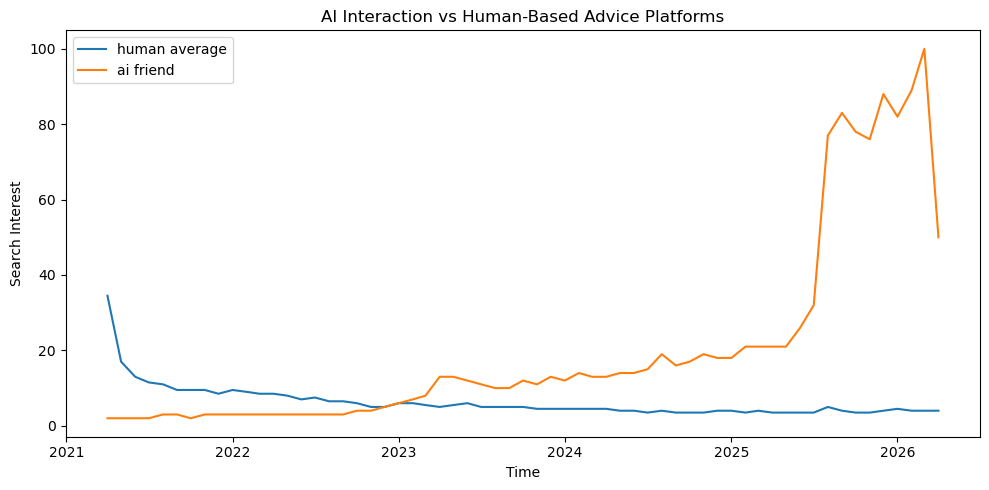

In [17]:
plt.figure(figsize=(10,5))
plt.plot(advice_df["Time"], advice_df["human_avg"], label="human average")
plt.plot(advice_df["Time"], advice_df["ai friend"], label="ai friend")
plt.title("AI Interaction vs Human-Based Advice Platforms")
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Show the difference between ai friend and the human-based advice average.

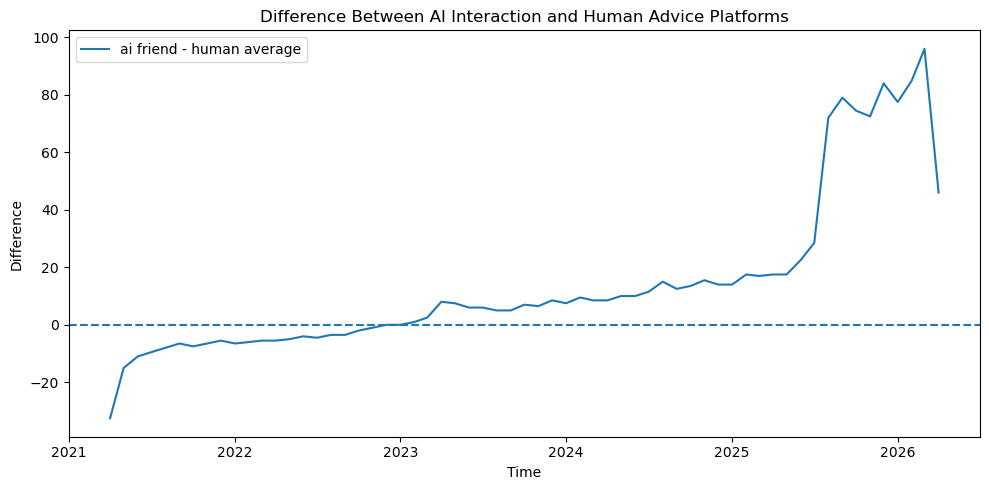

In [19]:
plt.figure(figsize=(10,5))
plt.plot(advice_df["Time"], advice_df["difference"], label="ai friend - human average")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI Interaction and Human Advice Platforms")
plt.xlabel("Time")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Show the relative strength of ai friend compared to the human-based advice average.

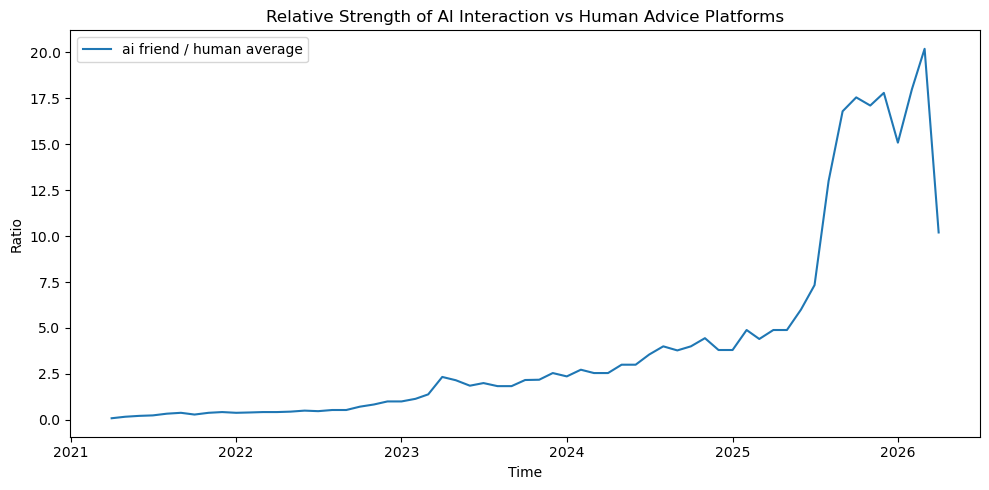

In [21]:
plt.figure(figsize=(10,5))
plt.plot(advice_df["Time"], advice_df["ratio"], label="ai friend / human average")
plt.title("Relative Strength of AI Interaction vs Human Advice Platforms")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Show the difference between chatgpt help and quora over time.

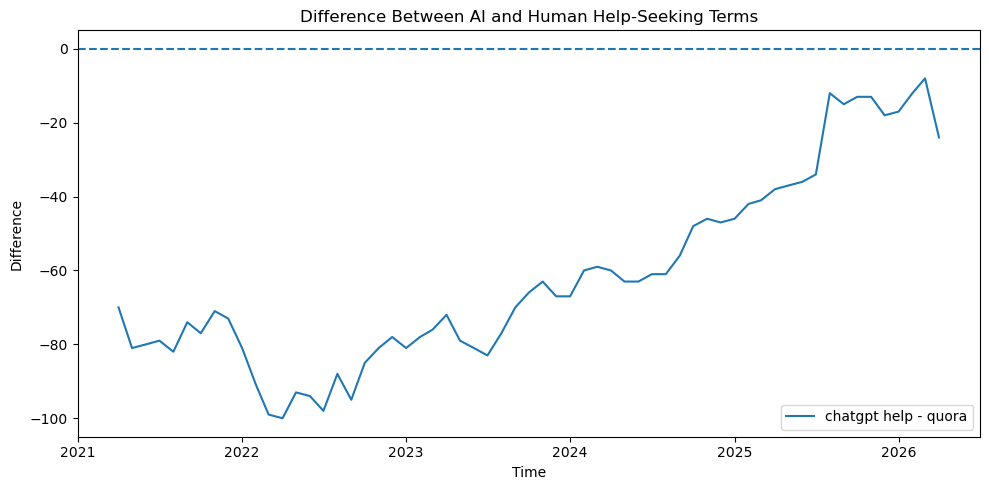

In [23]:
plt.figure(figsize=(10,5))
plt.plot(general_df["Time"], general_df["difference"], label="chatgpt help - quora")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI and Human Help-Seeking Terms")
plt.xlabel("Time")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Show the relative strength of chatgpt help compared to quora.

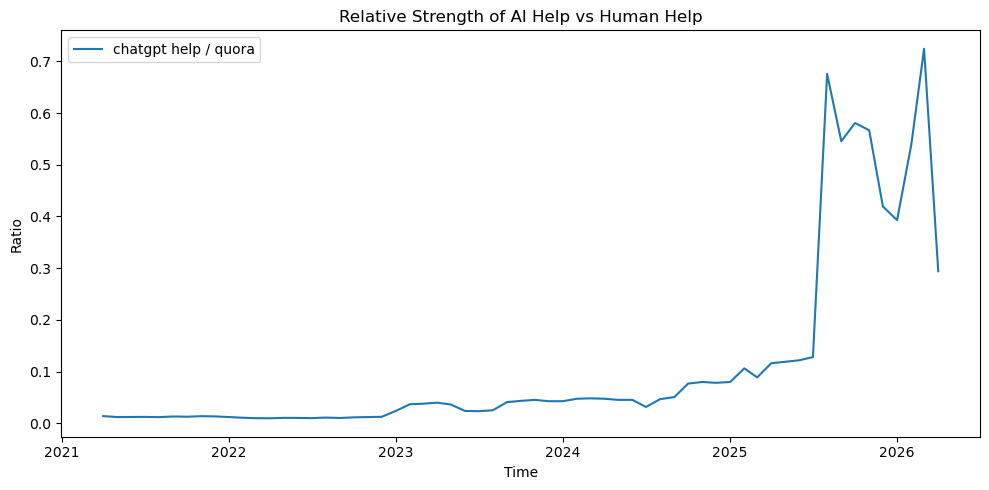

In [25]:
plt.figure(figsize=(10,5))
plt.plot(general_df["Time"], general_df["ratio"], label="chatgpt help / quora")
plt.title("Relative Strength of AI Help vs Human Help")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Compare chatgpt study with the human-based study average over time.

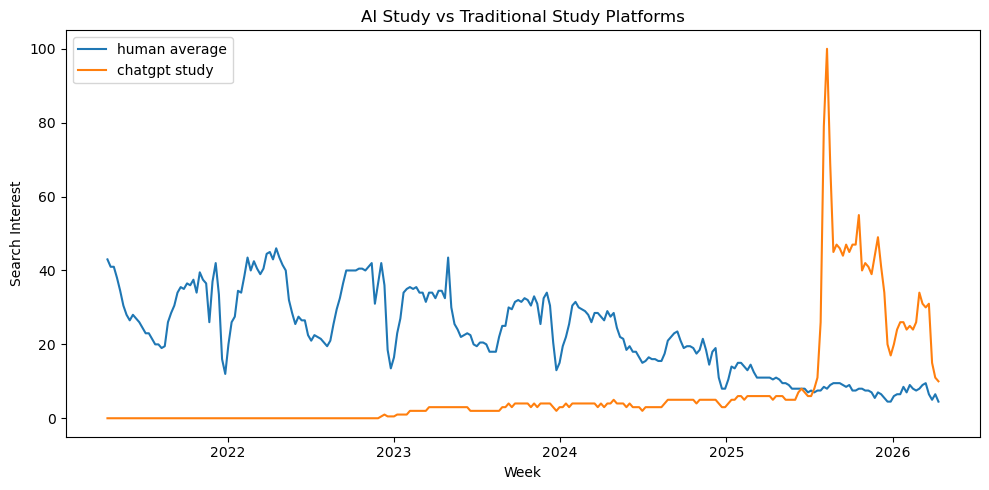

In [27]:
plt.figure(figsize=(10,5))
plt.plot(study_df["Week"], study_df["human_avg"], label="human average")
plt.plot(study_df["Week"], study_df["chatgpt study: (Worldwide)"], label="chatgpt study")
plt.title("AI Study vs Traditional Study Platforms")
plt.xlabel("Week")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Show the difference between chatgpt study and the human-based study average.

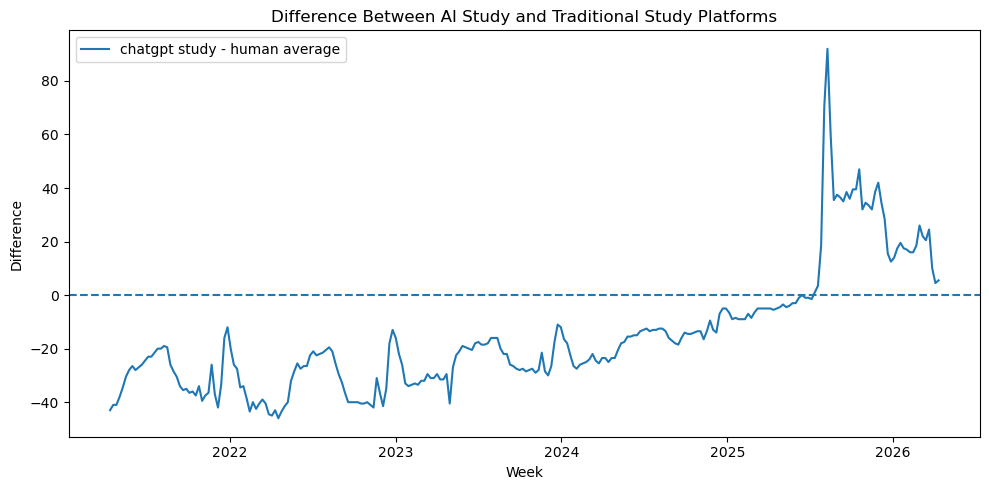

In [29]:
plt.figure(figsize=(10,5))
plt.plot(study_df["Week"], study_df["difference"], label="chatgpt study - human average")
plt.axhline(0, linestyle="--")
plt.title("Difference Between AI Study and Traditional Study Platforms")
plt.xlabel("Week")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Show the relative strength of chatgpt study compared to the human-based study average.

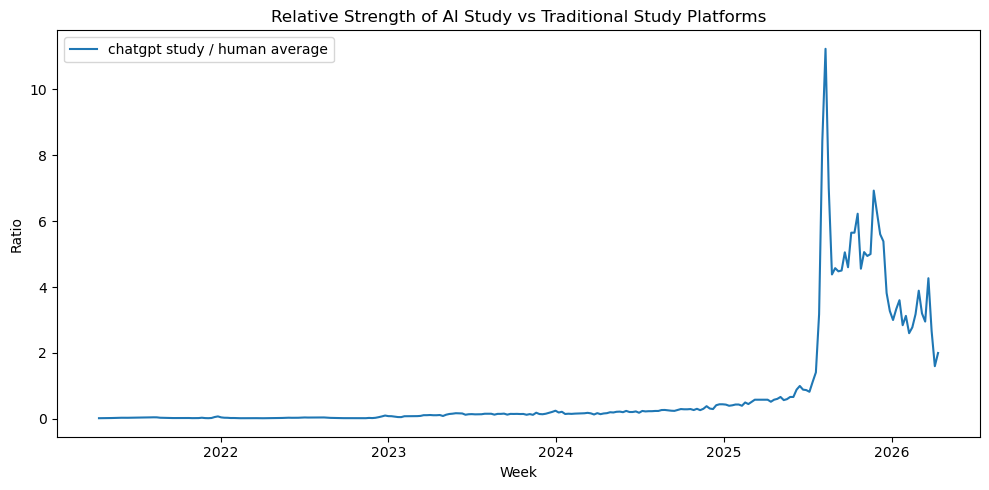

In [31]:
plt.figure(figsize=(10,5))
plt.plot(study_df["Week"], study_df["ratio"], label="chatgpt study / human average")
plt.title("Relative Strength of AI Study vs Traditional Study Platforms")
plt.xlabel("Week")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Hypothesis testing is used to examine whether the differences
# between AI-related and human-based search terms are statistically significant.

In [33]:
from scipy.stats import ttest_rel

print("Hypothesis Testing")

print("\n1) ai friend vs human-based advice average")
print("H0: There is no significant difference between ai friend and the human-based advice average.")
print("H1: There is a significant difference between ai friend and the human-based advice average.")
result1 = ttest_rel(advice_df["ai friend"], advice_df["human_avg"])
print(result1)
if result1.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.\n")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.\n")

print("2) chatgpt help vs quora")
print("H0: There is no significant difference between chatgpt help and quora.")
print("H1: There is a significant difference between chatgpt help and quora.")
result2 = ttest_rel(general_df["chatgpt help"], general_df["quora"])
print(result2)
if result2.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.\n")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.\n")

print("3) chatgpt study vs human-based study average")
print("H0: There is no significant difference between chatgpt study and the human-based study average.")
print("H1: There is a significant difference between chatgpt study and the human-based study average.")
result3 = ttest_rel(study_df["chatgpt study: (Worldwide)"], study_df["human_avg"])
print(result3)
if result3.pvalue < 0.05:
    print("Result: Reject H0. There is a statistically significant difference.\n")
else:
    print("Result: Fail to reject H0. There is no statistically significant difference.\n")

Hypothesis Testing

1) ai friend vs human-based advice average
H0: There is no significant difference between ai friend and the human-based advice average.
H1: There is a significant difference between ai friend and the human-based advice average.
TtestResult(statistic=np.float64(3.9375334858463025), pvalue=np.float64(0.00021693998710861778), df=np.int64(60))
Result: Reject H0. There is a statistically significant difference.

2) chatgpt help vs quora
H0: There is no significant difference between chatgpt help and quora.
H1: There is a significant difference between chatgpt help and quora.
TtestResult(statistic=np.float64(-18.78858939685996), pvalue=np.float64(8.121661607895409e-27), df=np.int64(60))
Result: Reject H0. There is a statistically significant difference.

3) chatgpt study vs human-based study average
H0: There is no significant difference between chatgpt study and the human-based study average.
H1: There is a significant difference between chatgpt study and the human-based